In [1]:
import numpy as np
import matplotlib.pyplot as plt

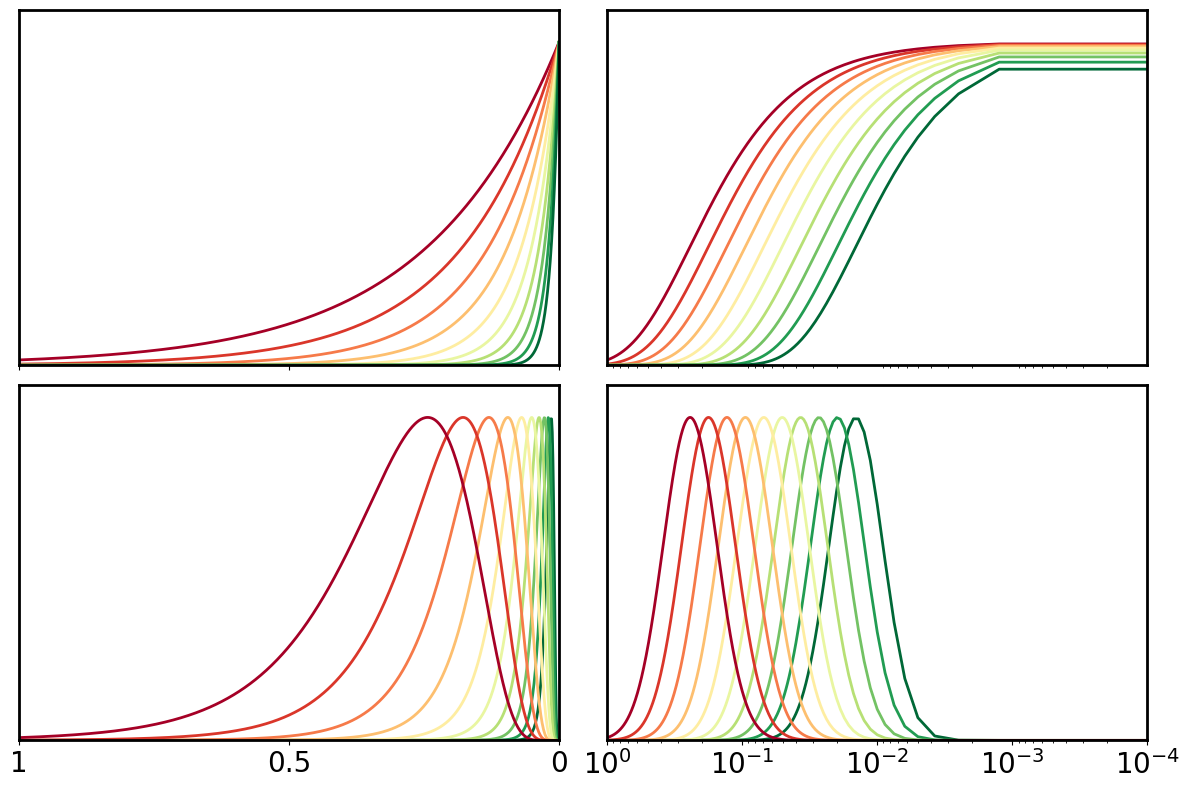

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 参数 ----------
n_curves = 10
theta_vals = np.linspace(-0.25*np.pi, 0.25*np.pi, n_curves)
theta_vals_norm = (theta_vals + 0.25 * np.pi) / (0.5 * np.pi)
s = 1.8
a = 0.18
r0 = 1.0
lamb_vals = np.exp((theta_vals + np.pi/2)*s)

# Domains
x_lin = np.linspace(0.0, 1.0, 800)
x_log = np.linspace(1e-5, 1.0, 800)  # 用于log坐标的定义域

# Colormap
cmap = plt.get_cmap('RdYlGn')
col_bump = cmap(theta_vals_norm)
col_edge = cmap(np.flip(theta_vals_norm))
# ---------- 定义函数 ----------
def bump_tuning(theta, x):
    x_safe = np.minimum(x, 1-1e-12)
    x_theta = np.exp(s*(theta - np.pi/2))
    return r0 * np.exp(-(np.log((1-x_safe)/x_theta))**2 / (4*(a*s)**2))

def edge_tuning(theta, x):
    lam = np.exp((theta+np.pi/2)*s)
    return np.exp(-lam * (1-x))

# ---------- 画图 ----------
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for ax_i in ax.flat:
    for spine in ax_i.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor('black')


# Bump in x-space (row 0, col 0)
for th, col in zip(theta_vals, col_bump):
    ax[0, 0].plot(x_lin, edge_tuning(th, x_lin), color=col, linewidth=2)
ax[0, 0].set_xlim([x_lin.min(), x_lin.max()])
ax[0, 0].set_ylim([0, 1.1])
ax[0, 0].set_xticks([0, 0.5, 1])
ax[0, 0].set_xticklabels([])
ax[0, 0].set_yticks([])

#ax[0, 0].set_title("Bump tuning (x-space)", fontsize=18)

# Bump in log-scale (row 0, col 1)
for th, col in zip(theta_vals, col_bump):
    ax[0, 1].plot(1 - x_log, edge_tuning(th, x_log), color=col, linewidth=2)
ax[0, 1].set_xscale('log')

ax[0, 1].invert_xaxis()   # 因为1-x从1到0
ax[0, 1].set_xticks([])
ax[0, 1].set_xlim([1, 1e-4])
ax[0, 1].set_ylim([0, 1.1])
ax[0, 1].set_yticks([])
#ax[0, 1].set_xlabel("1 - x (log scale)", fontsize=16)
#ax[0, 1].set_title("Bump tuning (log x-space)", fontsize=18)

# Edge in x-space (row 1, col 0)
for th, col in zip(theta_vals, col_edge):
    ax[1, 0].plot(x_lin, bump_tuning(th, x_lin), color=col, linewidth=2)
ax[1, 0].set_xlim([x_lin.min(), x_lin.max()])
ax[1, 0].set_ylim([0, 1.1])
ax[1, 0].set_xticks([0, 0.5, 1])
ax[1, 0].set_xticklabels([1, 0.5, 0], fontsize=20)
ax[1, 0].set_yticks([])
#ax[1, 0].set_title("Edge tuning (x-space)", fontsize=18)

# Edge in log-scale (row 1, col 1)
for th, col in zip(theta_vals, col_edge):
    ax[1, 1].plot(1 - x_log, bump_tuning(th, x_log), color=col, linewidth=2)
ax[1, 1].set_xscale('log')
ax[1, 1].tick_params(axis='x', labelsize=20)  # 修改x轴刻度字体大小

ax[1, 1].invert_xaxis()
ax[1, 1].set_xlim([1,1e-4])
ax[1, 1].set_ylim([0, 1.1])
ax[1, 1].set_yticks([])
#ax[1, 1].set_xlabel("1 - x (log scale)", fontsize=16)
#ax[1, 1].set_title("Edge tuning (log x-space)", fontsize=18)

plt.tight_layout()
plt.show()
